# CIFAR-10 Object Classification Project

A single, self-contained notebook for the AI-Engineering project **CIFAR Vision Objects**.
Goal: Classify 32×32 RGB photos into one of 10 everyday object classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).


## Contents of this notebook:

1. **Setup** — install/import the libraries we need and configure the GPU.
2. **Clean own photos** — walk through `data/own/`, remove broken/too-small images, strip privacy metadata.
3. **Load data** — download CIFAR-10 (60 000 images, automatic) and load your own photos resized to 32×32.
4. **Explore the data** — class distribution, sample grids, channel statistics.
5. **Build two models** — a small CNN trained from scratch + ResNet50 transfer learning.
6. **Train experiments** — baseline, baseline + own photos, transfer learning.
7. **Hyperparameter tuning** — small grid search.
8. **Evaluation** — accuracy, per-class F1, confusion matrix, mispredictions on both CIFAR-test and your own photos.
9. **Explainability** — Grad-CAM heatmaps showing where the model is looking.
10. **Predict a single image** — ready-to-use inference function.



* The first cell installs Python packages (uncomment the line if you have not already installed them).
* The notebook runs on CPU only, but if GPUs are available, TensorFlow will automatically use them. You can check GPU availability with `tf.config.list_physical_devices('GPU')`.

## 0. Install dependencies

In [1]:
pip install tensorflow==2.20.0 keras==3.12.0 matplotlib==3.9.2 numpy==1.26.4 scikit-learn==1.5.2 pillow==10.4.0 pandas==2.2.3

## 1. Imports + configuration

In [2]:
import os, json, itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import load_model, Model

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

print('TensorFlow :', tf.__version__)
print('Keras      :', tf.keras.__version__)

TensorFlow : 2.20.0
Keras      : 3.12.0


In [3]:
# ---------------------------------------------------------------------------
# Paths for data, models and output
# ---------------------------------------------------------------------------
ROOT        = Path.cwd()
DATA_DIR    = ROOT / 'data'
OWN_DIR     = DATA_DIR / 'own'
MODELS_DIR  = ROOT / 'models'
REPORTS_DIR = ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
TABLES_DIR  = REPORTS_DIR / 'tables'
for d in (DATA_DIR, OWN_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# define some constants
# ---------------------------------------------------------------------------
IMG_SIZE     = 32
NUM_CLASSES  = 10
CHANNELS     = 3
CLASS_NAMES  = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ---------------------------------------------------------------------------
# Hyperparams for training
# ---------------------------------------------------------------------------
SEED                    = 42      # makes runs reproducible
BATCH_SIZE              = 64      # this may be lowered if you run out gpu memory
EPOCHS                  = 50      # max epochs
LEARNING_RATE           = 1e-3
EARLY_STOPPING_PATIENCE = 8
VALIDATION_SPLIT_SIZE   = 5000    # how many CIFAR-train images we hold out for validation

# Quick-mode: shrink epoch counts so you can do a fast end-to-end smoke test.
# Set QUICK_MODE = False for the real training run that goes into your report.
QUICK_MODE = False
if QUICK_MODE:
    EPOCHS = 3
    print('QUICK_MODE on — epochs reduced to', EPOCHS)

# Reproducibility seeds
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('ROOT        =', ROOT)
print('OWN_DIR     =', OWN_DIR)
print('MODELS_DIR  =', MODELS_DIR)
print('REPORTS_DIR =', REPORTS_DIR)

ROOT        = /content
OWN_DIR     = /content/data/own
MODELS_DIR  = /content/models
REPORTS_DIR = /content/reports


In [4]:
# ---------------------------------------------------------------------------
# GPU setup (safe on CPU-only laptops too)
# ---------------------------------------------------------------------------
# Keep memory growth on so TensorFlow only reserves the GPU memory it needs.
# Mixed precision can speed up training on supported GPUs.
USE_MIXED_PRECISION = True

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Found {len(gpus)} GPU(s):')
    for i, g in enumerate(gpus):
        print(f'  [{i}] {g.name}')
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print('GPU memory growth: ON')
    except RuntimeError as e:
        print('Could not enable memory growth:', e)
    if USE_MIXED_PRECISION:
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision policy:', mixed_precision.global_policy().name)
else:
    print('No GPU detected. Training will run on CPU (slower but works).')
    USE_MIXED_PRECISION = False

Found 1 GPU(s):
  [0] /physical_device:GPU:0
GPU memory growth: ON
Mixed precision policy: mixed_float16


## 2. Validate and clean your own photos

`data/own/` has one folder per class (`0_airplane/`, `1_automobile/`, ...). The next cell:

* skips files that are not images (`.json`, `.pickle`, hidden files, etc.);
* opens every image to verify it is not corrupted;
* removes images smaller than 32×32 (they would have to be upscaled, which is misleading);
* optionally **strips EXIF metadata** (GPS, camera serial number) for privacy;
* optionally **deletes** the bad files in place.

The first run is a *dry run* (it just lists what would be removed). The second cell does the actual removal.

In [5]:
def clean_own_folder(delete_bad: bool = False, strip_exif: bool = False, min_side: int = 32):
    """Walk data/own/ and validate every image. Returns a summary DataFrame."""
    rows = []
    for ci, name in enumerate(CLASS_NAMES):
        folder = OWN_DIR / f'{ci}_{name}'
        if not folder.exists():
            rows.append((name, 0, 0, 0))
            continue
        kept = removed = non_image = 0
        for f in sorted(folder.iterdir()):
            if not f.is_file():
                continue
            if f.suffix.lower() not in SUPPORTED_EXT:
                non_image += 1
                continue
            try:
                # 1. integrity check
                with Image.open(f) as im:
                    im.verify()
                # 2. size check (re-open since verify() consumes the file)
                with Image.open(f) as im:
                    w, h = im.size
                    if min(w, h) < min_side:
                        raise ValueError(f'too small: {w}x{h}')
                    if strip_exif and f.suffix.lower() in {'.jpg', '.jpeg'}:
                        clean = Image.new('RGB', im.size)
                        clean.putdata(list(im.convert('RGB').getdata()))
                        clean.save(f, 'JPEG', quality=92)
                kept += 1
            except Exception as e:
                if delete_bad:
                    f.unlink(missing_ok=True)
                    removed += 1
                else:
                    print(f'  [BAD]  {f.relative_to(OWN_DIR)} -> {e}')
                    removed += 1
        rows.append((name, kept, removed, non_image))
    return pd.DataFrame(rows, columns=['class', 'kept', 'bad', 'non-image-files'])

print('Dry run — nothing has been deleted yet.')
print('Files marked [BAD] will be deleted only if you set delete_bad=True in the next cell.\n')
clean_own_folder(delete_bad=False, strip_exif=False)

Dry run — nothing has been deleted yet.
Files marked [BAD] will be deleted only if you set delete_bad=True in the next cell.



,class,kept,bad,non-image-files
0,airplane,32,0,0
1,automobile,55,0,0
2,bird,68,0,1
3,cat,78,0,2
4,deer,68,0,1
5,dog,53,0,1
6,frog,78,0,1
7,horse,55,0,1
8,ship,26,0,1
9,truck,29,0,1


In [6]:
# Real cleanup pass.  Comment this cell out (or change delete_bad=False) if you
# want to keep every file untouched.
# note from testing: stripping the exif data takes quite a long time, so you might want to set strip_exif=False
result = clean_own_folder(delete_bad=True, strip_exif=True, min_side=32)
print(result)
print('\nTotal photos kept :', int(result['kept'].sum()))
print('Total deleted     :', int(result['bad'].sum()))
print('Non-image files   :', int(result['non-image-files'].sum()), '(ignored, not deleted)')

        class  kept  bad  non-image-files
0    airplane    32    0                0
1  automobile    55    0                0
2        bird    68    0                1
3         cat    78    0                2
4        deer    68    0                1
5         dog    53    0                1
6        frog    78    0                1
7       horse    55    0                1
8        ship    26    0                1
9       truck    29    0                1

Total photos kept : 542
Total deleted     : 0
Non-image files   : 9 (ignored, not deleted)


## 3. Load CIFAR-10 and your own photos

* **CIFAR-10** is downloaded automatically the first time (~170 MB, then cached in `~/.keras/`).
* We split the 50 000 training images into **45 000 train + 5 000 validation** with a fixed seed.
  The 10 000 test images are *never* used during training.
* **Own photos** are resized from their original size to 32×32 to match CIFAR.

In [7]:
def load_cifar10():
    (x_full, y_full), (x_test, y_test) = cifar10.load_data()
    y_full = y_full.flatten()
    y_test = y_test.flatten()
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(x_full))
    x_full, y_full = x_full[idx], y_full[idx]
    x_val,   y_val   = x_full[:VALIDATION_SPLIT_SIZE], y_full[:VALIDATION_SPLIT_SIZE]
    x_train, y_train = x_full[VALIDATION_SPLIT_SIZE:], y_full[VALIDATION_SPLIT_SIZE:]
    print(f'CIFAR-10 -> train={len(x_train)}  val={len(x_val)}  test={len(x_test)}')
    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_cifar10()
print('shape sanity check:', x_train.shape, x_train.dtype, '| pixel range', x_train.min(), '..', x_train.max())

CIFAR-10 -> train=45000  val=5000  test=10000
shape sanity check: (45000, 32, 32, 3) uint8 | pixel range 0 .. 255


In [8]:
def load_own_images():
    Xs, ys, skipped = [], [], 0
    for ci, name in enumerate(CLASS_NAMES):
        folder = OWN_DIR / f'{ci}_{name}'
        if not folder.exists():
            continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() not in SUPPORTED_EXT:
                continue
            try:
                img = Image.open(f).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                Xs.append(np.asarray(img, dtype=np.uint8))
                ys.append(ci)
            except Exception as e:
                print(f'  skip {f.name}: {e}')
                skipped += 1
    if not Xs:
        return (np.empty((0, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8),
                np.empty((0,), dtype=np.int64))
    X = np.stack(Xs)
    y = np.array(ys, dtype=np.int64)
    print(f'Own images: {len(X)} loaded ({skipped} skipped)')
    for ci in range(NUM_CLASSES):
        print(f'  {ci}_{CLASS_NAMES[ci]:10s}: {(y == ci).sum():3d} images')
    return X, y

X_own, y_own = load_own_images()

Own images: 542 loaded (0 skipped)
  0_airplane  :  32 images
  1_automobile:  55 images
  2_bird      :  68 images
  3_cat       :  78 images
  4_deer      :  68 images
  5_dog       :  53 images
  6_frog      :  78 images
  7_horse     :  55 images
  8_ship      :  26 images
  9_truck     :  29 images


In [9]:
def split_own(X, y, train_fraction=0.6):
    """60/40 shuffle of own images: 60% added to training, 40% kept as own-test."""
    if len(X) == 0:
        empty = (np.empty((0,) + X.shape[1:], dtype=X.dtype),
                 np.empty((0,), dtype=y.dtype))
        return empty, empty
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(X))
    cut = int(len(X) * train_fraction)
    return (X[idx[:cut]], y[idx[:cut]]), (X[idx[cut:]], y[idx[cut:]])

def build_splits(include_own_in_training: bool):
    """Return train/val/test_cifar/test_own arrays for a chosen experiment."""
    if include_own_in_training and len(X_own) > 0:
        (xo_tr, yo_tr), (xo_te, yo_te) = split_own(X_own, y_own)
        x_tr = np.concatenate([x_train, xo_tr], axis=0)
        y_tr = np.concatenate([y_train, yo_tr], axis=0)
        print(f'Added {len(xo_tr)} own images to training (new size {len(x_tr)})')
    else:
        x_tr, y_tr = x_train, y_train
        xo_te, yo_te = X_own, y_own
    return {
        'train':      (x_tr,  y_tr),
        'val':        (x_val, y_val),
        'test_cifar': (x_test, y_test),
        'test_own':   (xo_te, yo_te),
    }

## 4. Exploratory Data Analysis

Before training any model we look at the dataset to spot problems (class imbalance, weird pixel values, etc.).
All plots below are saved into `reports/figures/` so you can paste them into the report.

In [10]:
df_dist = pd.DataFrame({
    'class':       CLASS_NAMES,
    'cifar_train': [int((y_train == i).sum()) for i in range(10)],
    'cifar_test':  [int((y_test  == i).sum()) for i in range(10)],
    'own':         [int((y_own   == i).sum()) for i in range(10)] if len(y_own) else [0] * 10,
})
df_dist.to_csv(TABLES_DIR / 'eda_class_distribution.csv', index=False)
df_dist

,class,cifar_train,cifar_test,own
0,airplane,4527,1000,32
1,automobile,4458,1000,55
2,bird,4465,1000,68
3,cat,4518,1000,78
4,deer,4477,1000,68
5,dog,4527,1000,53
6,frog,4498,1000,78
7,horse,4531,1000,55
8,ship,4482,1000,26
9,truck,4517,1000,29


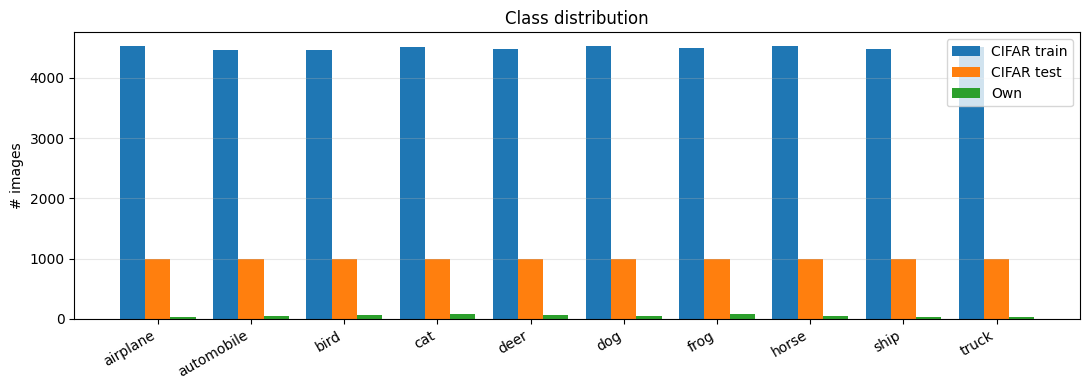

saved /content/reports/figures/eda_class_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(CLASS_NAMES))
w = 0.27
ax.bar(x - w, df_dist['cifar_train'], w, label='CIFAR train')
ax.bar(x,     df_dist['cifar_test'],  w, label='CIFAR test')
ax.bar(x + w, df_dist['own'],         w, label='Own')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('# images'); ax.set_title('Class distribution')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
out = FIGURES_DIR / 'eda_class_distribution.png'
fig.savefig(out, dpi=150); plt.show()
print('saved', out)

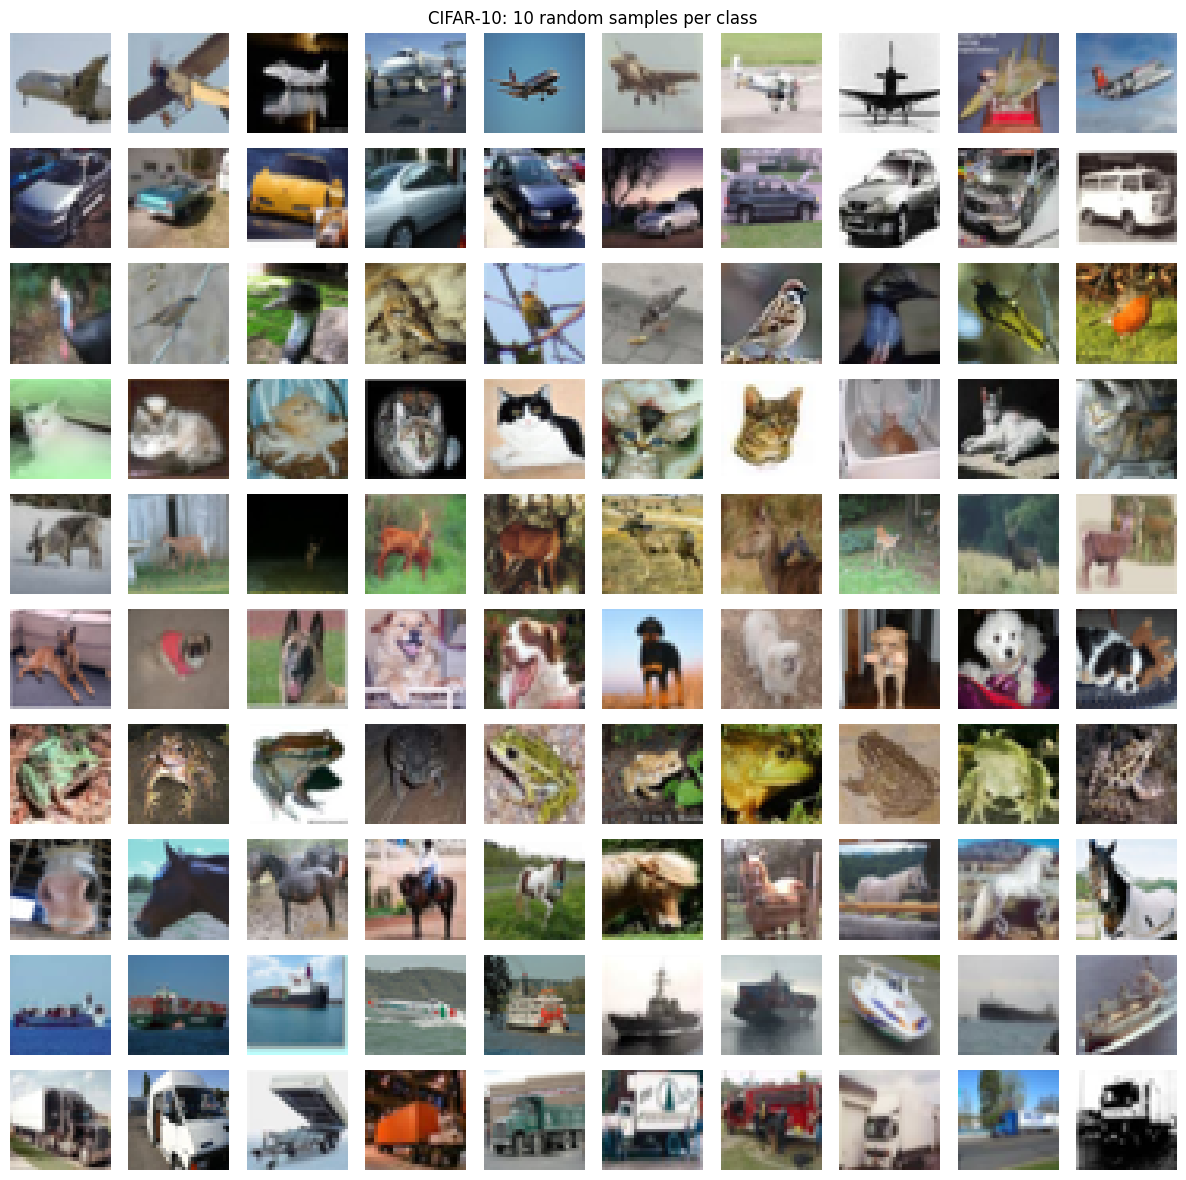

saved /content/reports/figures/eda_cifar_samples.png


In [12]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for ci, name in enumerate(CLASS_NAMES):
    pool = np.where(y_train == ci)[0]
    picks = rng.choice(pool, size=10, replace=False)
    for j, idx in enumerate(picks):
        ax = axes[ci, j]
        ax.imshow(x_train[idx]); ax.axis('off')
        if j == 0:
            ax.set_ylabel(name, rotation=0, labelpad=40, fontsize=10, ha='right', va='center')
fig.suptitle('CIFAR-10: 10 random samples per class')
fig.tight_layout()
out = FIGURES_DIR / 'eda_cifar_samples.png'
fig.savefig(out, dpi=150); plt.show()
print('saved', out)

Channel means (R, G, B): [125.19999694824219, 122.9000015258789, 113.9000015258789]
Channel stds  (R, G, B): [63.0, 62.099998474121094, 66.69999694824219]


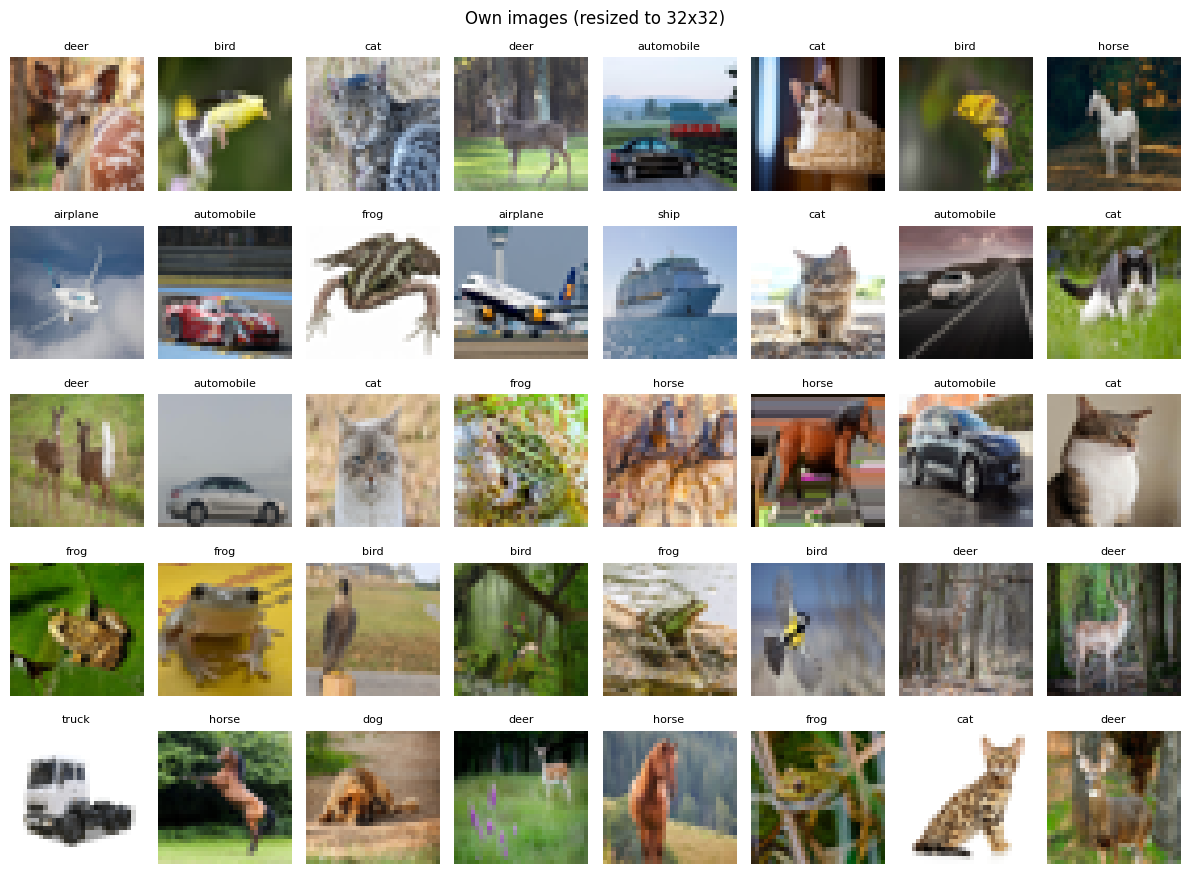

saved /content/reports/figures/eda_own_samples.png


In [13]:
means = x_train.astype(np.float32).mean(axis=(0, 1, 2))
stds  = x_train.astype(np.float32).std(axis=(0, 1, 2))
print(f'Channel means (R, G, B): {means.round(1).tolist()}')
print(f'Channel stds  (R, G, B): {stds.round(1).tolist()}')

if len(X_own) > 0:
    n = min(40, len(X_own))
    cols = 8
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 1.8 * rows))
    axes = axes.flatten()
    rng2 = np.random.default_rng(1)
    show_idx = rng2.choice(len(X_own), size=n, replace=False)
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off'); continue
        idx = show_idx[i]
        ax.imshow(X_own[idx]); ax.set_title(CLASS_NAMES[y_own[idx]], fontsize=8); ax.axis('off')
    fig.suptitle('Own images (resized to 32x32)')
    fig.tight_layout()
    out = FIGURES_DIR / 'eda_own_samples.png'
    fig.savefig(out, dpi=150); plt.show()
    print('saved', out)
else:
    print('No own images available — add some to data/own/ and re-run.')

## 5. Model architectures

We build two **substantively different** models so we can compare them later:

### Model A — baseline CNN trained from scratch
A small 3-block convolutional network (~158 k parameters). Reaches ~80% accuracy on CIFAR-10.

### Model B — ResNet50 transfer learning (pre-trained on ImageNet)
ResNet50 was trained on 1.4 M ImageNet photos and already understands generic object features. We **freeze**
its weights and train only a small classifier head on top. Usually beats the baseline.

Both models accept raw `uint8` images in 0..255 and normalise inside the model so the calling code stays simple.

In [14]:
def _augmentation_block():
    """Random transforms applied during TRAINING only — reduces overfitting.
    No vertical flip (an upside-down airplane is a wrong training signal)."""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.10, 0.10),
    ], name='augmentation')

def build_baseline_cnn(learning_rate: float = LEARNING_RATE, dropout: float = 0.5):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    x = _augmentation_block()(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    # Block 1: 32 filters
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout / 2)(x)

    # Block 2: 64 filters
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout / 2)(x)

    # Block 3: 128 filters + global pooling
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='predictions')(x)

    model = models.Model(inputs, outputs, name='baseline_cnn')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

def build_transfer_model(learning_rate: float = LEARNING_RATE, fine_tune: bool = False):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    x = _augmentation_block()(inputs)
    x = layers.Resizing(96, 96)(x)
    x = layers.Lambda(resnet_preprocess_input, name='resnet_preprocess')(x)
    backbone = ResNet50(input_shape=(96, 96, 3),
                           include_top=False, weights='imagenet',
                           pooling='avg')
    backbone.trainable = fine_tune
    x = backbone(x, training=fine_tune)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='predictions')(x)

    model = models.Model(inputs, outputs, name='resnet50_transfer')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

print('--- baseline_cnn ---')
build_baseline_cnn().summary()
print('\n--- resnet50_transfer ---')
build_transfer_model().summary()

--- baseline_cnn ---


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,506 (619.16 KB)

 Trainable params: 157,866 (616.66 KB)

...

Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preprocess (Lambda)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 6. Training utilities

The `train_model` function below trains any model with the same callbacks so the comparison is fair.

* **EarlyStopping** — stop training when the validation accuracy stops improving for `EARLY_STOPPING_PATIENCE` epochs.
* **ModelCheckpoint** — always save the *best* model seen so far to `models/<run_name>.keras`.
* **ReduceLROnPlateau** — halve the learning rate if validation loss plateaus.
* **CSVLogger** — record per-epoch metrics to `reports/tables/history_<run_name>.csv`.

The function also saves a JSON config and a PNG with loss & accuracy curves.

In [15]:
def plot_curves(history, run_name: str):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, h['loss'], label='train')
    axes[0].plot(epochs, h['val_loss'], label='val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss — {run_name}'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, h['accuracy'], label='train')
    axes[1].plot(epochs, h['val_accuracy'], label='val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy — {run_name}'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    out = FIGURES_DIR / f'curves_{run_name}.png'
    fig.tight_layout(); fig.savefig(out, dpi=150); plt.show()
    print('saved', out)

def train_model(model, run_name: str, splits, epochs=None, batch_size=BATCH_SIZE):
    if epochs is None:
        epochs = EPOCHS
    x_tr, y_tr = splits['train']
    x_va, y_va = splits['val']
    model_path = MODELS_DIR / f'{run_name}.keras'
    log_path   = TABLES_DIR / f'history_{run_name}.csv'
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=EARLY_STOPPING_PATIENCE,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=str(model_path), monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                          min_lr=1e-6, verbose=1),
        CSVLogger(str(log_path), append=False),
    ]
    history = model.fit(
        x_tr, y_tr, validation_data=(x_va, y_va),
        batch_size=batch_size, epochs=epochs, callbacks=callbacks, verbose=2)
    cfg = {
        'run_name': run_name,
        'model_name': model.name,
        'epochs_max': epochs,
        'epochs_run': len(history.history['loss']),
        'batch_size': batch_size,
        'best_val_accuracy': float(max(history.history['val_accuracy'])),
        'training_size': int(len(x_tr)),
        'validation_size': int(len(x_va)),
    }
    with open(TABLES_DIR / f'config_{run_name}.json', 'w') as fp:
        json.dump(cfg, fp, indent=2)
    plot_curves(history, run_name)
    print(f"\n[{run_name}] best val_accuracy = {cfg['best_val_accuracy']:.4f}, saved to {model_path}")
    return history

## 7. Run the experiments

Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.41300, saving model to /content/models/exp1_baseline.keras
704/704 - 39s - 56ms/step - accuracy: 0.4057 - loss: 1.6309 - val_accuracy: 0.4130 - val_loss: 1.8247 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_accuracy improved from 0.41300 to 0.49060, saving model to /content/models/exp1_baseline.keras
704/704 - 14s - 20ms/step - accuracy: 0.5263 - loss: 1.3287 - val_accuracy: 0.4906 - val_loss: 1.5144 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_accuracy improved from 0.49060 to 0.56340, saving model to /content/models/exp1_baseline.keras
704/704 - 21s - 30ms/step - accuracy: 0.5760 - loss: 1.2038 - val_accuracy: 0.5634 - val_loss: 1.2462 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_accuracy improved from 0.56340 to 0.57520, saving model to /content/models/exp1_baseline.keras
704/704 - 14s - 20ms/step - accuracy: 0.6104 - loss: 1.1120 - val_accuracy: 0.5752 - val_loss: 1.3049 - learning_rate: 0.0010
Epoch 5/50

Epoch 5

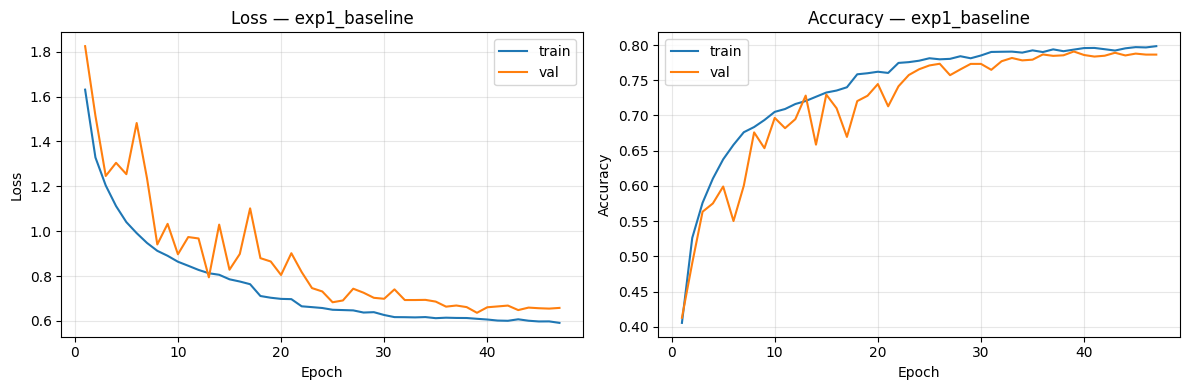

saved /content/reports/figures/curves_exp1_baseline.png

[exp1_baseline] best val_accuracy = 0.7908, saved to /content/models/exp1_baseline.keras


In [16]:
# Experiment 1 — baseline CNN, CIFAR-10 only
# In this output you can see that it trained for 50 epochs but then reverted back to the best epoch (45) due to restore function best_weights=True
splits_cifar = build_splits(include_own_in_training=False)
model_baseline = build_baseline_cnn()
hist_baseline = train_model(model_baseline, run_name='exp1_baseline', splits=splits_cifar)

Added 325 own images to training (new size 45325)
Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.42620, saving model to /content/models/exp3_with_own.keras
709/709 - 25s - 36ms/step - accuracy: 0.4028 - loss: 1.6280 - val_accuracy: 0.4262 - val_loss: 1.8778 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_accuracy improved from 0.42620 to 0.46180, saving model to /content/models/exp3_with_own.keras
709/709 - 14s - 20ms/step - accuracy: 0.5235 - loss: 1.3303 - val_accuracy: 0.4618 - val_loss: 1.8029 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_accuracy improved from 0.46180 to 0.57240, saving model to /content/models/exp3_with_own.keras
709/709 - 21s - 29ms/step - accuracy: 0.5758 - loss: 1.1949 - val_accuracy: 0.5724 - val_loss: 1.3260 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_accuracy improved from 0.57240 to 0.58160, saving model to /content/models/exp3_with_own.keras
709/709 - 14s - 20ms/step - accuracy: 0.6151 - loss: 1.1042 - val_accuracy: 0.5816 - val_loss: 

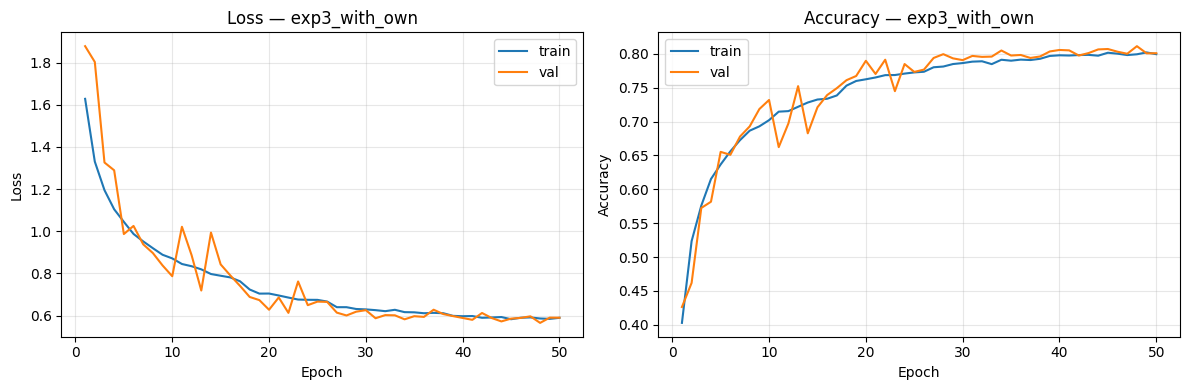

saved /content/reports/figures/curves_exp3_with_own.png

[exp3_with_own] best val_accuracy = 0.8112, saved to /content/models/exp3_with_own.keras


In [17]:
# Experiment 3 — baseline CNN, with 60% of own images mixed into training
splits_with_own = build_splits(include_own_in_training=True)
model_with_own = build_baseline_cnn()
hist_with_own = train_model(model_with_own, run_name='exp3_with_own', splits=splits_with_own)

Epoch 1/50

Epoch 1: val_accuracy improved from None to 0.80380, saving model to /content/models/exp5_transfer.keras
704/704 - 46s - 66ms/step - accuracy: 0.6340 - loss: 1.2133 - val_accuracy: 0.8038 - val_loss: 0.6179 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_accuracy improved from 0.80380 to 0.82640, saving model to /content/models/exp5_transfer.keras
704/704 - 32s - 45ms/step - accuracy: 0.6996 - loss: 0.9482 - val_accuracy: 0.8264 - val_loss: 0.5286 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_accuracy did not improve from 0.82640
704/704 - 30s - 43ms/step - accuracy: 0.7061 - loss: 0.9142 - val_accuracy: 0.8084 - val_loss: 0.5703 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_accuracy did not improve from 0.82640
704/704 - 30s - 43ms/step - accuracy: 0.7062 - loss: 0.9066 - val_accuracy: 0.8168 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 5/50

Epoch 5: val_accuracy did not improve from 0.82640
704/704 - 33s - 46ms/step - accuracy: 0.7077 - loss: 0.9028 - val_accu

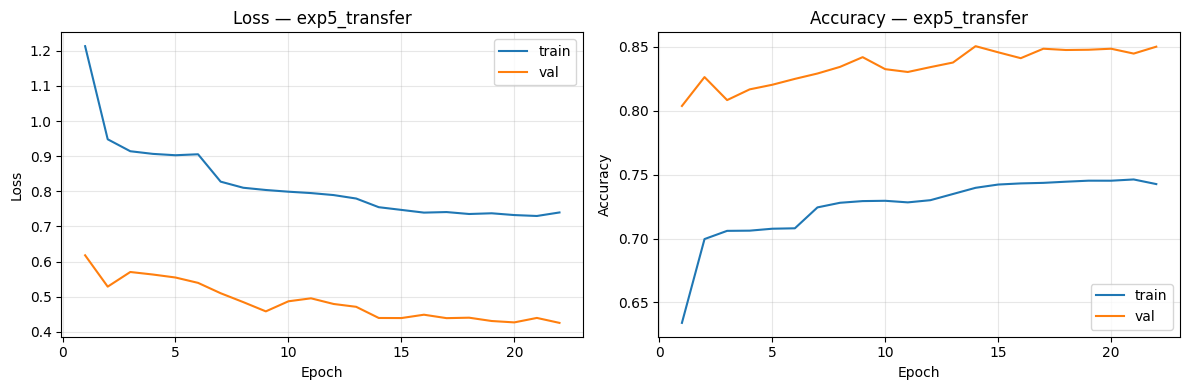

saved /content/reports/figures/curves_exp5_transfer.png

[exp5_transfer] best val_accuracy = 0.8506, saved to /content/models/exp5_transfer.keras


In [18]:
# Experiment 5 — ResNet50 transfer learning on CIFAR-10
model_transfer = build_transfer_model()
hist_transfer = train_model(model_transfer, run_name='exp5_transfer', splits=splits_cifar)

## 8. Evaluation utilities

For every trained model we compute:

* **Accuracy** — fraction of correct predictions (single headline number).
* **Macro-F1** — our primary optimising metric (treats every class equally; robust to imbalance).
* **Per-class precision/recall/F1** — saved to CSV.
* **Confusion matrix** — PNG; reveals which classes the model confuses.
* **Sample-prediction grid** — PNG; 25 random examples with green/red title for correct/wrong.
* **Worst mispredictions** — PNG of the 10 images where the model was most confidently wrong.

In [19]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0)
    return {
        'accuracy': float(acc),
        'precision_macro': float(prec.mean()),
        'recall_macro':    float(rec.mean()),
        'f1_macro':        float(f1.mean()),
        'per_class': {'class': CLASS_NAMES,
                      'precision': prec.tolist(),
                      'recall':    rec.tolist(),
                      'f1':        f1.tolist(),
                      'support':   sup.tolist()},
    }

def plot_confusion_matrix(cm, out_path, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    n = len(CLASS_NAMES)
    ax.set_xticks(range(n)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(CLASS_NAMES)
    thresh = cm.max() / 2.0 if cm.max() > 0 else 1
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=9)
    fig.colorbar(im, ax=ax); fig.tight_layout()
    fig.savefig(out_path, dpi=150); plt.show()
    print('saved', out_path)

def plot_sample_predictions(model, x, y, out_path, n=25):
    if len(x) == 0:
        return
    rng = np.random.default_rng(0)
    idx = rng.choice(len(x), size=min(n, len(x)), replace=False)
    preds = model.predict(x[idx], verbose=0).argmax(axis=1)
    rows = int(np.ceil(len(idx) / 5))
    fig, axes = plt.subplots(rows, 5, figsize=(12, 2.5 * rows))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i >= len(idx):
            ax.axis('off'); continue
        ax.imshow(x[idx[i]])
        t = CLASS_NAMES[y[idx[i]]]; p = CLASS_NAMES[preds[i]]
        ok = (y[idx[i]] == preds[i])
        ax.set_title(f'T:{t}\nP:{p}', color=('green' if ok else 'red'), fontsize=9)
        ax.axis('off')
    fig.tight_layout(); fig.savefig(out_path, dpi=150); plt.show()
    print('saved', out_path)

def plot_misclassified(model, x, y, out_path, n=10):
    if len(x) == 0:
        return
    probs = model.predict(x, verbose=0)
    preds = probs.argmax(axis=1)
    wrong = np.where(preds != y)[0]
    if len(wrong) == 0:
        print('No misclassifications — perfect accuracy.')
        return
    wrong_conf = probs[wrong, preds[wrong]]
    worst = wrong[np.argsort(-wrong_conf)][:n]
    cols = 5; rows = int(np.ceil(len(worst) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.8 * rows))
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i >= len(worst):
            ax.axis('off'); continue
        idx = worst[i]
        ax.imshow(x[idx])
        ax.set_title(f'T:{CLASS_NAMES[y[idx]]}\nP:{CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.2f})',
                     color='red', fontsize=9)
        ax.axis('off')
    fig.tight_layout(); fig.savefig(out_path, dpi=150); plt.show()
    print('saved', out_path)

def evaluate_split(model, x, y, split_name: str, run_name: str):
    if len(x) == 0:
        print(f'split {split_name!r} is empty — skipping')
        return None
    preds = model.predict(x, verbose=0).argmax(axis=1)
    metrics = compute_metrics(y, preds)
    print(f'\n--- {split_name} ({run_name}) ---')
    print(classification_report(y, preds, target_names=CLASS_NAMES, digits=3, zero_division=0))
    pc = metrics['per_class']
    pd.DataFrame({
        'class': pc['class'], 'precision': pc['precision'],
        'recall': pc['recall'], 'f1': pc['f1'], 'support': pc['support'],
    }).to_csv(TABLES_DIR / f'metrics_{split_name}_{run_name}.csv', index=False)
    cm = confusion_matrix(y, preds, labels=list(range(NUM_CLASSES)))
    plot_confusion_matrix(cm,
                          FIGURES_DIR / f'confusion_matrix_{split_name}_{run_name}.png',
                          title=f'Confusion Matrix — {split_name} — {run_name}')
    return metrics


--- cifar (exp1_baseline) ---
              precision    recall  f1-score   support

    airplane      0.846     0.797     0.821      1000
  automobile      0.880     0.921     0.900      1000
        bird      0.796     0.649     0.715      1000
         cat      0.744     0.595     0.661      1000
        deer      0.801     0.698     0.746      1000
         dog      0.832     0.615     0.707      1000
        frog      0.595     0.946     0.731      1000
       horse      0.863     0.843     0.853      1000
        ship      0.864     0.871     0.868      1000
       truck      0.762     0.923     0.835      1000

    accuracy                          0.786     10000
   macro avg      0.798     0.786     0.784     10000
weighted avg      0.798     0.786     0.784     10000



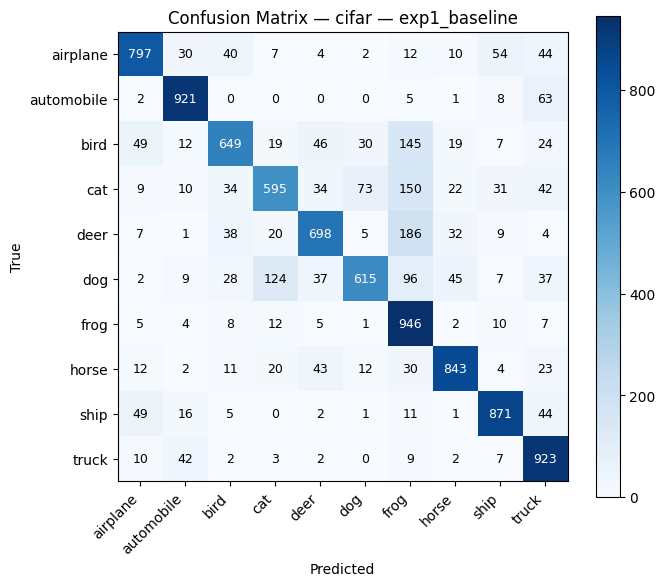

saved /content/reports/figures/confusion_matrix_cifar_exp1_baseline.png

--- own (exp1_baseline) ---
              precision    recall  f1-score   support

    airplane      0.619     0.812     0.703        32
  automobile      0.961     0.891     0.925        55
        bird      0.662     0.632     0.647        68
         cat      0.863     0.564     0.682        78
        deer      0.682     0.662     0.672        68
         dog      0.610     0.472     0.532        53
        frog      0.574     0.795     0.667        78
       horse      0.792     0.691     0.738        55
        ship      0.806     0.962     0.877        26
       truck      0.718     0.966     0.824        29

    accuracy                          0.710       542
   macro avg      0.729     0.745     0.726       542
weighted avg      0.726     0.710     0.708       542



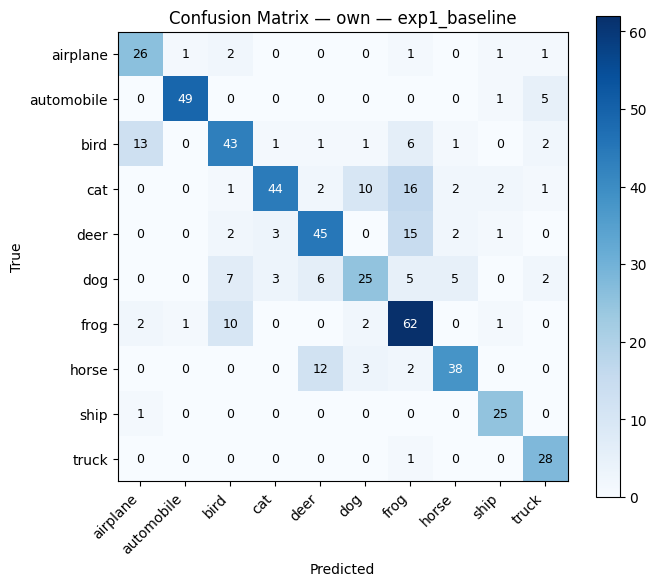

saved /content/reports/figures/confusion_matrix_own_exp1_baseline.png


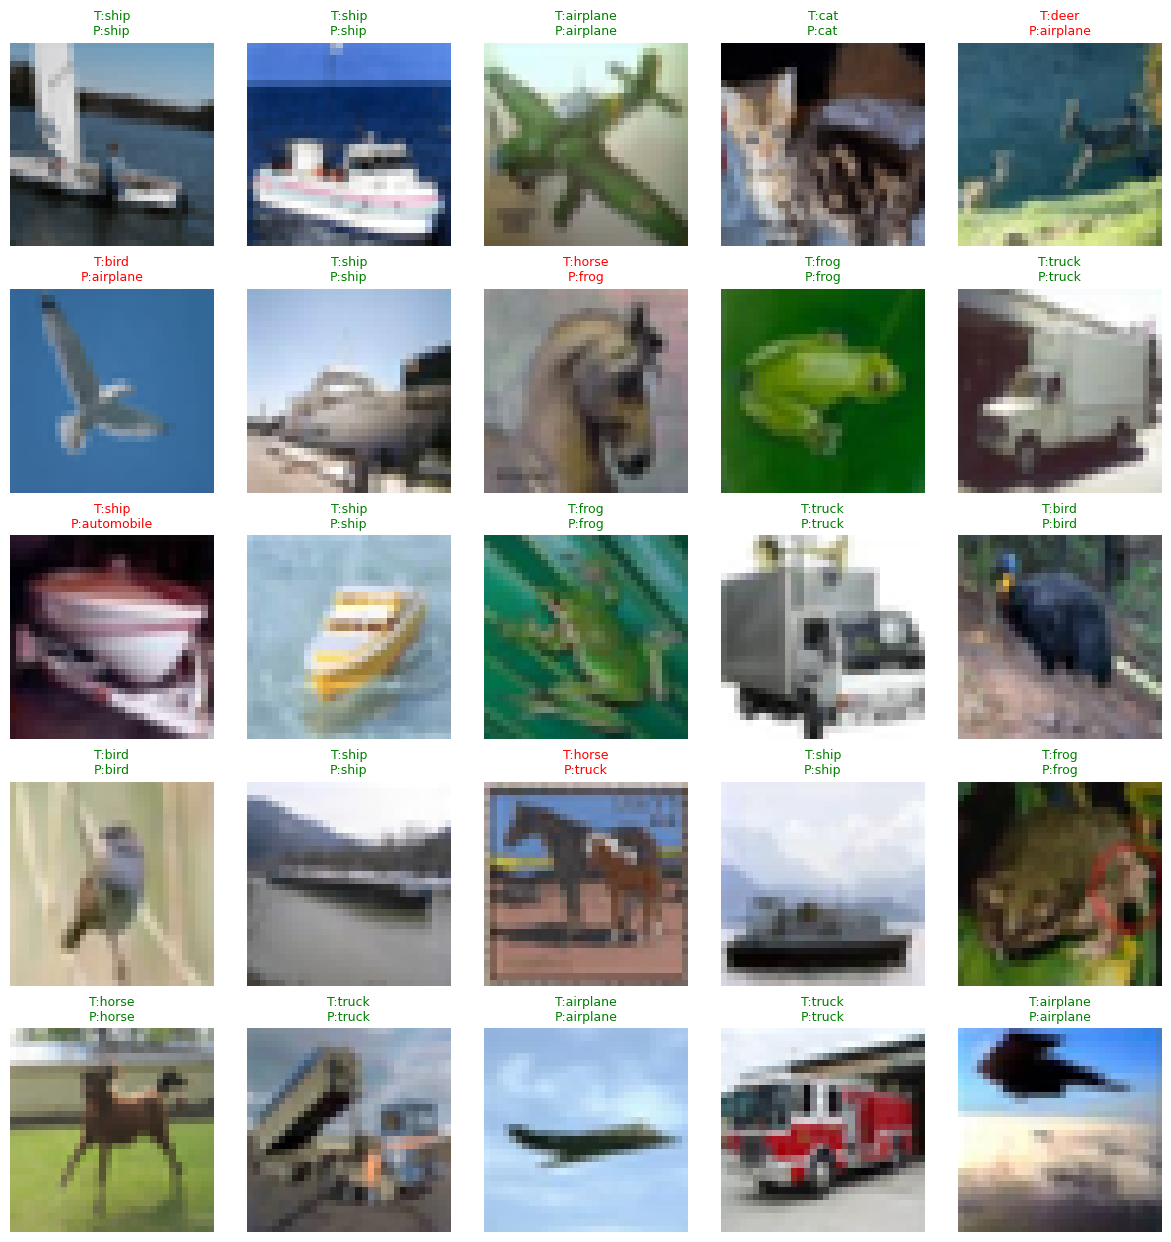

saved /content/reports/figures/sample_predictions_exp1_baseline.png


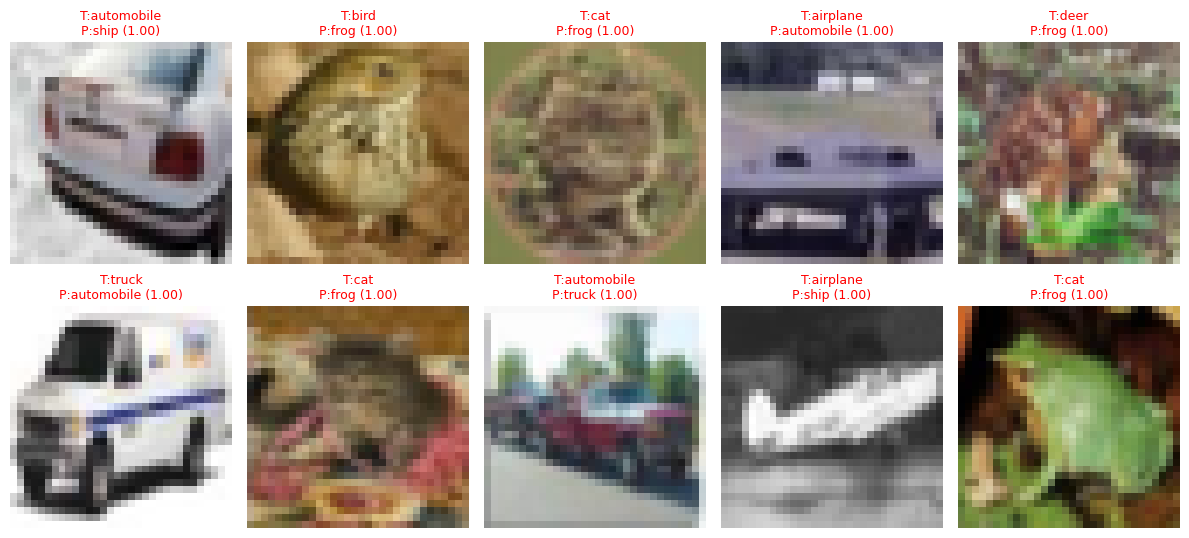

saved /content/reports/figures/misclassified_exp1_baseline.png

--- cifar (exp3_with_own) ---
              precision    recall  f1-score   support

    airplane      0.844     0.826     0.835      1000
  automobile      0.888     0.928     0.908      1000
        bird      0.779     0.747     0.763      1000
         cat      0.731     0.609     0.664      1000
        deer      0.794     0.755     0.774      1000
         dog      0.847     0.604     0.705      1000
        frog      0.661     0.939     0.776      1000
       horse      0.833     0.847     0.840      1000
        ship      0.906     0.878     0.892      1000
       truck      0.818     0.910     0.861      1000

    accuracy                          0.804     10000
   macro avg      0.810     0.804     0.802     10000
weighted avg      0.810     0.804     0.802     10000



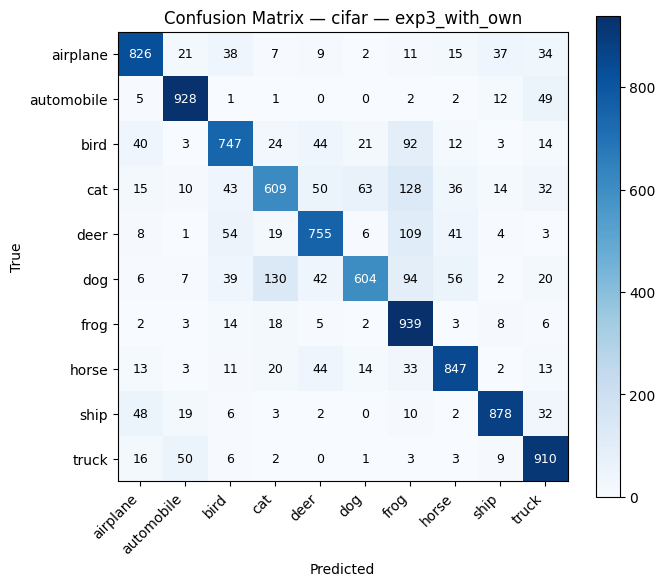

saved /content/reports/figures/confusion_matrix_cifar_exp3_with_own.png

--- own (exp3_with_own) ---
              precision    recall  f1-score   support

    airplane      0.694     0.781     0.735        32
  automobile      0.891     0.891     0.891        55
        bird      0.632     0.706     0.667        68
         cat      0.820     0.641     0.719        78
        deer      0.675     0.824     0.742        68
         dog      0.703     0.491     0.578        53
        frog      0.718     0.782     0.748        78
       horse      0.771     0.673     0.718        55
        ship      0.862     0.962     0.909        26
       truck      0.812     0.897     0.852        29

    accuracy                          0.744       542
   macro avg      0.758     0.765     0.756       542
weighted avg      0.748     0.744     0.740       542



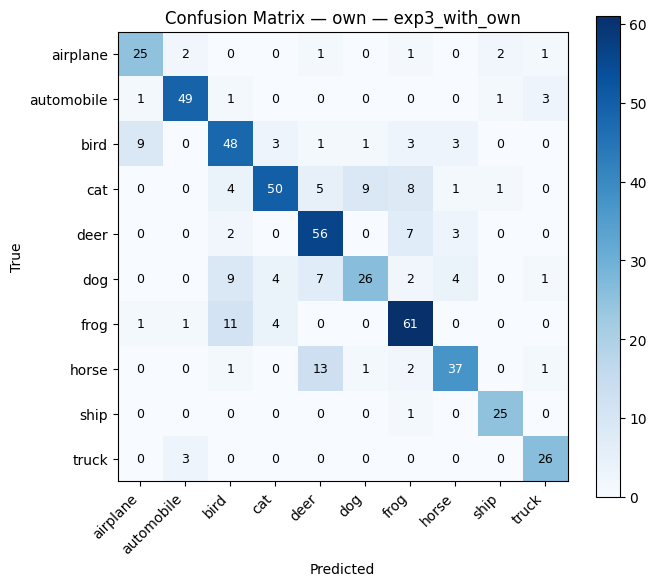

saved /content/reports/figures/confusion_matrix_own_exp3_with_own.png


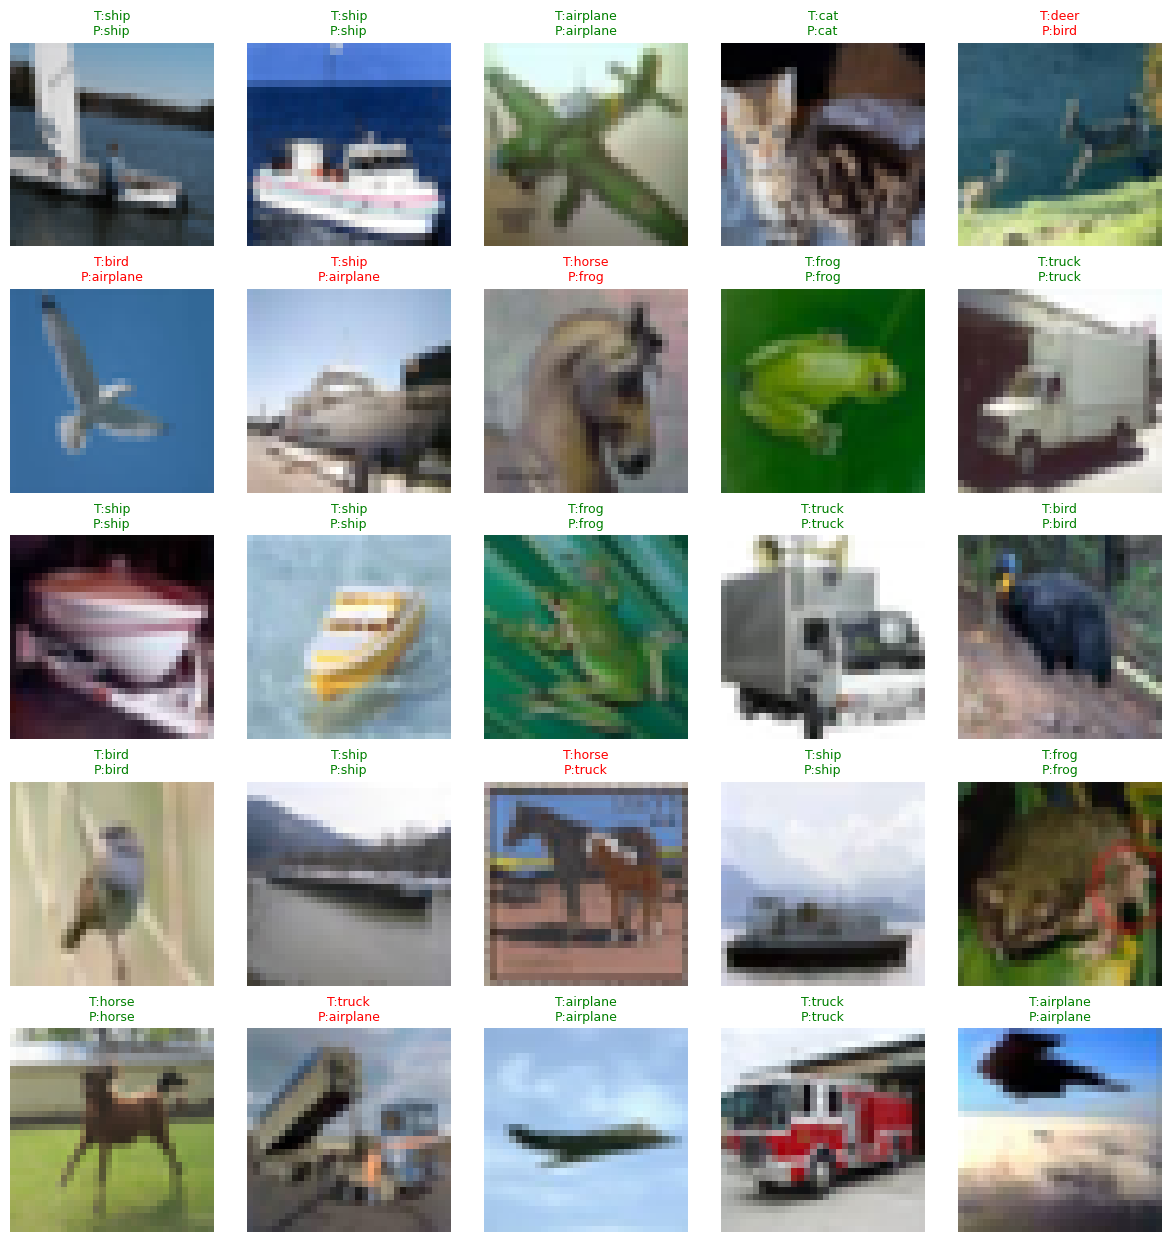

saved /content/reports/figures/sample_predictions_exp3_with_own.png


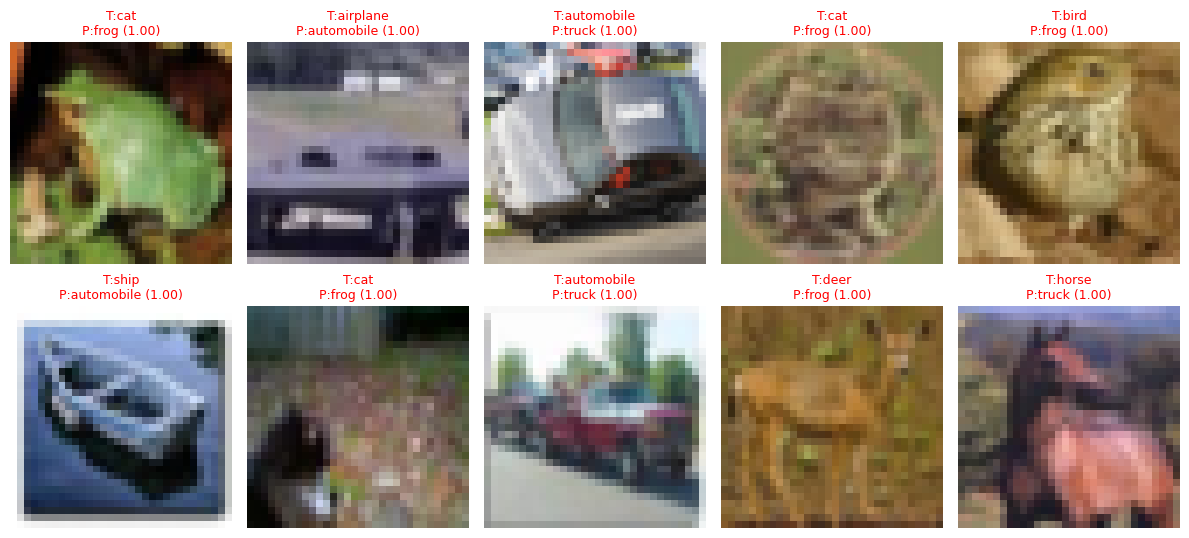

saved /content/reports/figures/misclassified_exp3_with_own.png
Rebuilding exp5_transfer architecture to load weights safely...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



--- cifar (exp5_transfer) ---
              precision    recall  f1-score   support

    airplane      0.861     0.850     0.856      1000
  automobile      0.879     0.930     0.904      1000
        bird      0.891     0.773     0.828      1000
         cat      0.764     0.701     0.731      1000
        deer      0.860     0.752     0.803      1000
         dog      0.821     0.800     0.810      1000
        frog      0.797     0.933     0.860      1000
       horse      0.821     0.898     0.858      1000
        ship      0.908     0.916     0.912      1000
       truck      0.854     0.895     0.874      1000

    accuracy                          0.845     10000
   macro avg      0.846     0.845     0.843     10000
weighted avg      0.846     0.845     0.843     10000



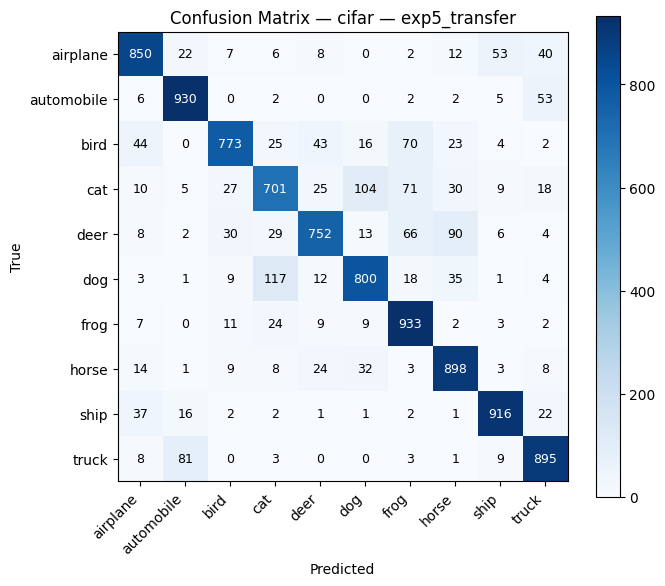

saved /content/reports/figures/confusion_matrix_cifar_exp5_transfer.png

--- own (exp5_transfer) ---
              precision    recall  f1-score   support

    airplane      0.604     1.000     0.753        32
  automobile      0.889     0.873     0.881        55
        bird      0.847     0.735     0.787        68
         cat      0.871     0.782     0.824        78
        deer      0.771     0.794     0.783        68
         dog      0.686     0.660     0.673        53
        frog      0.776     0.756     0.766        78
       horse      0.729     0.782     0.754        55
        ship      0.957     0.846     0.898        26
       truck      0.815     0.759     0.786        29

    accuracy                          0.786       542
   macro avg      0.795     0.799     0.791       542
weighted avg      0.797     0.786     0.787       542



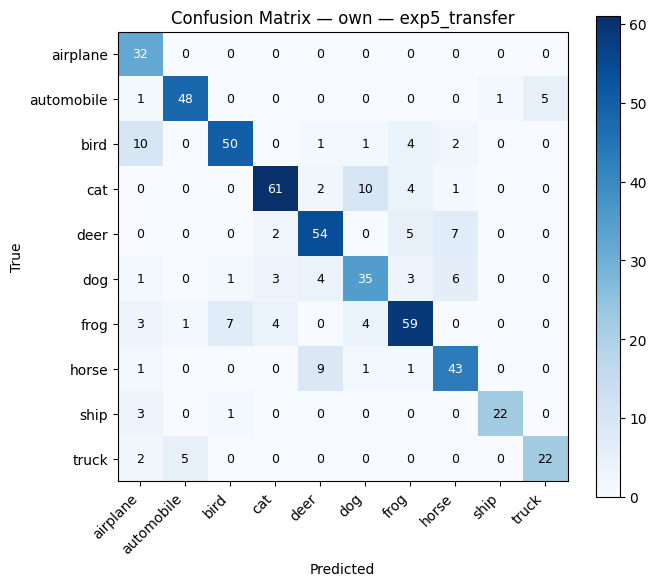

saved /content/reports/figures/confusion_matrix_own_exp5_transfer.png


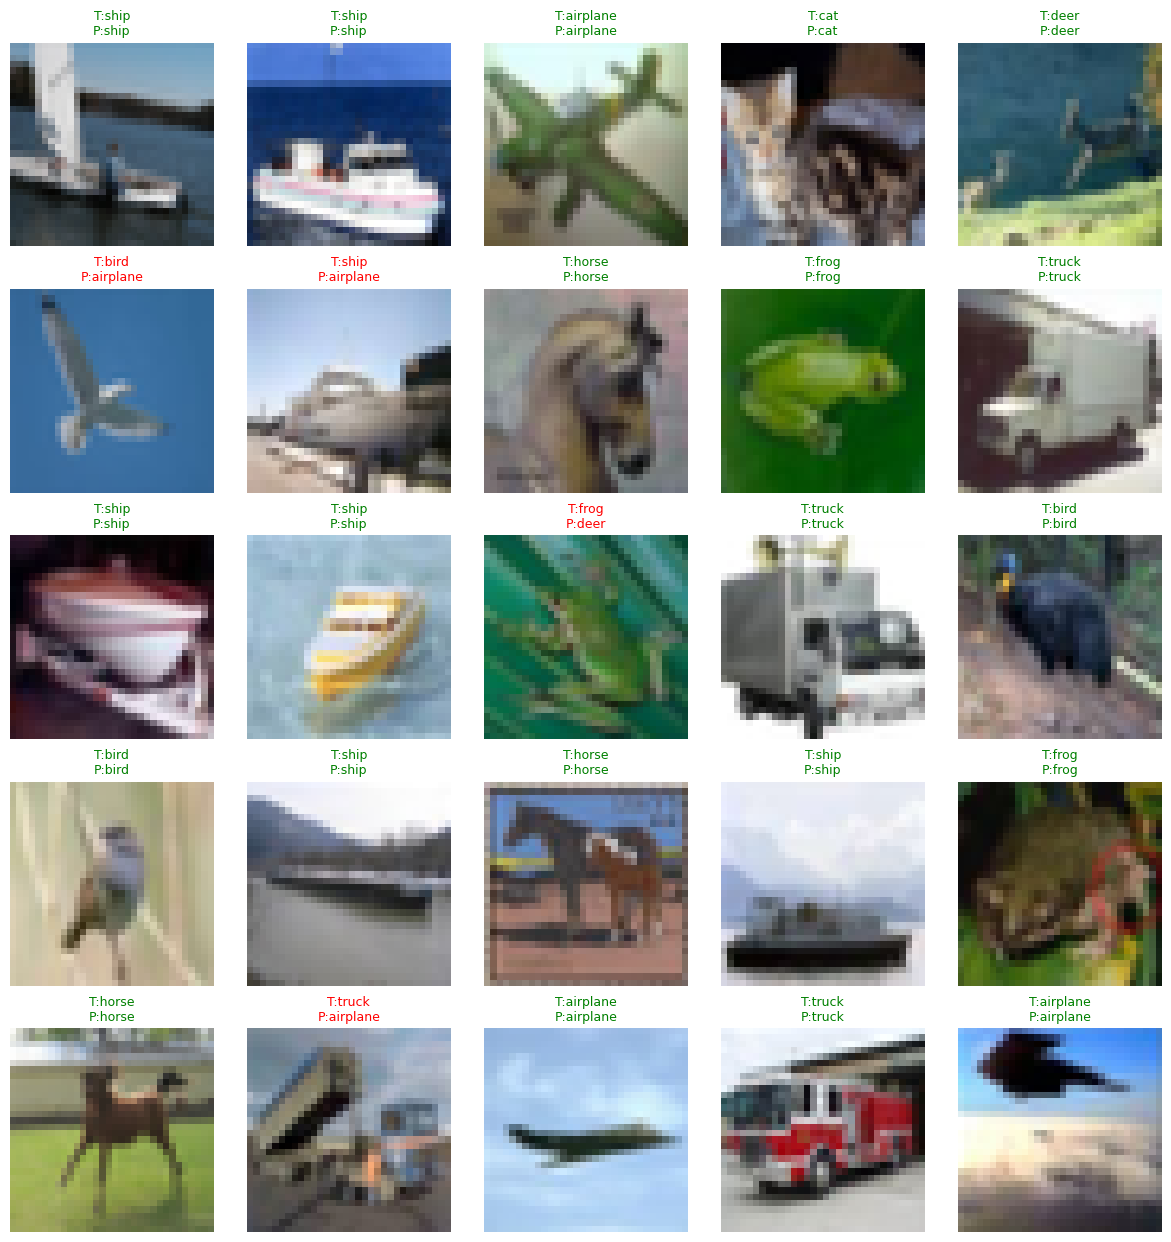

saved /content/reports/figures/sample_predictions_exp5_transfer.png


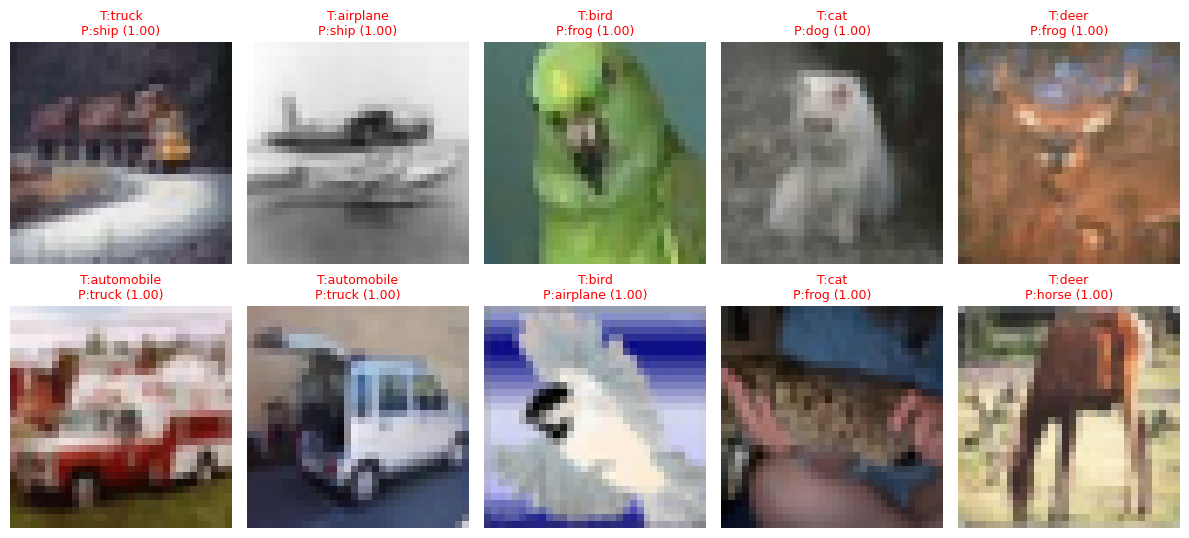

saved /content/reports/figures/misclassified_exp5_transfer.png

=== Comparison across runs ===
          run split  accuracy  precision_macro  recall_macro  f1_macro
exp1_baseline cifar  0.785800         0.798346      0.785800  0.783610
exp1_baseline   own  0.710332         0.728583      0.744616  0.726483
exp3_with_own cifar  0.804300         0.810015      0.804300  0.801735
exp3_with_own   own  0.743542         0.757706      0.764603  0.756026
exp5_transfer cifar  0.844800         0.845625      0.844800  0.843453
exp5_transfer   own  0.785978         0.794572      0.798757  0.790538

saved /content/reports/tables/summary_all.csv


In [20]:
def evaluate_run(run_name: str):
    """Load the saved model for a run and evaluate it on CIFAR-test and own-test."""
    model_path = MODELS_DIR / f'{run_name}.keras'
    if not model_path.exists():
        print(f'no model file at {model_path} — train first.')
        return None

    if run_name == 'exp5_transfer':
        print(f"Rebuilding {run_name} architecture to load weights safely...")
        # Recreate the exact structure using your existing function
        model = build_transfer_model()
        # Load the weights directly out of the saved .keras file
        model.load_weights(model_path)
    else:
        # The baseline and own-test runs don't use Lambda layers, so they load normally
        model = load_model(model_path)

    splits = build_splits(include_own_in_training=False)
    m_cifar = evaluate_split(model, *splits['test_cifar'], 'cifar', run_name)
    m_own   = evaluate_split(model, *splits['test_own'],   'own',   run_name)
    plot_sample_predictions(model, *splits['test_cifar'],
                            FIGURES_DIR / f'sample_predictions_{run_name}.png')
    plot_misclassified(model, *splits['test_cifar'],
                       FIGURES_DIR / f'misclassified_{run_name}.png')
    rows = []
    for name, m in [('cifar', m_cifar), ('own', m_own)]:
        if m is None:
            continue
        rows.append({'run': run_name, 'split': name,
                     'accuracy': m['accuracy'],
                     'precision_macro': m['precision_macro'],
                     'recall_macro':    m['recall_macro'],
                     'f1_macro':        m['f1_macro']})
    df = pd.DataFrame(rows)
    df.to_csv(TABLES_DIR / f'summary_{run_name}.csv', index=False)
    return df

summaries = []
for run in ('exp1_baseline', 'exp3_with_own', 'exp5_transfer'):
    s = evaluate_run(run)
    if s is not None:
        summaries.append(s)
if summaries:
    big = pd.concat(summaries, ignore_index=True)
    big.to_csv(TABLES_DIR / 'summary_all.csv', index=False)
    print('\n=== Comparison across runs ===')
    print(big.to_string(index=False))
    print('\nsaved', TABLES_DIR / 'summary_all.csv')

## 9. Hyperparameter tuning

Small grid over learning rate and dropout, with shorter training per trial. Each row of the resulting CSV is a
run; the best row is the winning configuration.

In [21]:
def hp_grid_search(epochs_per_trial: int = 8, short: bool = True):
    learning_rates = [1e-3, 5e-4] if short else [1e-3, 5e-4, 1e-4]
    dropouts       = [0.3, 0.5]
    combos = list(itertools.product(learning_rates, dropouts))
    print(f'Running {len(combos)} HP trials with {epochs_per_trial} epochs each')

    results = []
    for i, (lr, drop) in enumerate(combos, start=1):
        print(f'\n=== trial {i}/{len(combos)} : lr={lr}  dropout={drop} ===')
        m = build_baseline_cnn(learning_rate=lr, dropout=drop)
        h = m.fit(x_train, y_train, validation_data=(x_val, y_val),
                  batch_size=BATCH_SIZE, epochs=epochs_per_trial, verbose=2,
                  callbacks=[EarlyStopping(monitor='val_accuracy', patience=3,
                                           restore_best_weights=True)])
        best = float(max(h.history['val_accuracy']))
        results.append({'trial': i, 'learning_rate': lr, 'dropout': drop,
                        'best_val_accuracy': best,
                        'final_train_accuracy': float(h.history['accuracy'][-1]),
                        'final_val_accuracy':   float(h.history['val_accuracy'][-1])})
    df = pd.DataFrame(results).sort_values('best_val_accuracy', ascending=False).reset_index(drop=True)
    df.to_csv(TABLES_DIR / 'hp_results.csv', index=False)
    best_row = df.iloc[0].to_dict()
    with open(TABLES_DIR / 'hp_best.json', 'w') as fp:
        json.dump(best_row, fp, indent=2)
    print('\nBest combo:', best_row)
    return df

hp_results = hp_grid_search(epochs_per_trial=8, short=True)
hp_results

Running 4 HP trials with 8 epochs each

=== trial 1/4 : lr=0.001  dropout=0.3 ===
Epoch 1/8
704/704 - 20s - 29ms/step - accuracy: 0.4348 - loss: 1.5511 - val_accuracy: 0.4316 - val_loss: 1.5939
Epoch 2/8
704/704 - 14s - 20ms/step - accuracy: 0.5567 - loss: 1.2382 - val_accuracy: 0.4012 - val_loss: 2.1594
Epoch 3/8
704/704 - 14s - 20ms/step - accuracy: 0.6179 - loss: 1.0897 - val_accuracy: 0.5894 - val_loss: 1.2242
Epoch 4/8
704/704 - 14s - 20ms/step - accuracy: 0.6467 - loss: 1.0020 - val_accuracy: 0.6152 - val_loss: 1.1556
Epoch 5/8
704/704 - 14s - 20ms/step - accuracy: 0.6771 - loss: 0.9275 - val_accuracy: 0.6570 - val_loss: 1.0732
Epoch 6/8
704/704 - 14s - 21ms/step - accuracy: 0.6931 - loss: 0.8829 - val_accuracy: 0.6436 - val_loss: 1.0491
Epoch 7/8
704/704 - 14s - 20ms/step - accuracy: 0.7079 - loss: 0.8434 - val_accuracy: 0.6748 - val_loss: 0.9350
Epoch 8/8
704/704 - 14s - 20ms/step - accuracy: 0.7191 - loss: 0.8106 - val_accuracy: 0.6686 - val_loss: 0.9937

=== trial 2/4 : lr=0.

,trial,learning_rate,dropout,best_val_accuracy,final_train_accuracy,final_val_accuracy
0,1,0.0010,0.3,0.6748,0.719067,0.6686
1,3,0.0005,0.3,0.6656,0.690778,0.6656
2,4,0.0005,0.5,0.6384,0.661089,0.6384
3,2,0.0010,0.5,0.6068,0.681000,0.6068


## 10. Grad-CAM explainability

Grad-CAM produces a heatmap that highlights which pixels pushed the model toward its prediction. Red areas
in the overlay are the parts of the image the model paid most attention to. We pick three confidently-correct
and three confidently-wrong examples from the CIFAR test set so the report has interpretable evidence

Rebuilding exp5_transfer architecture to load weights safely...
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


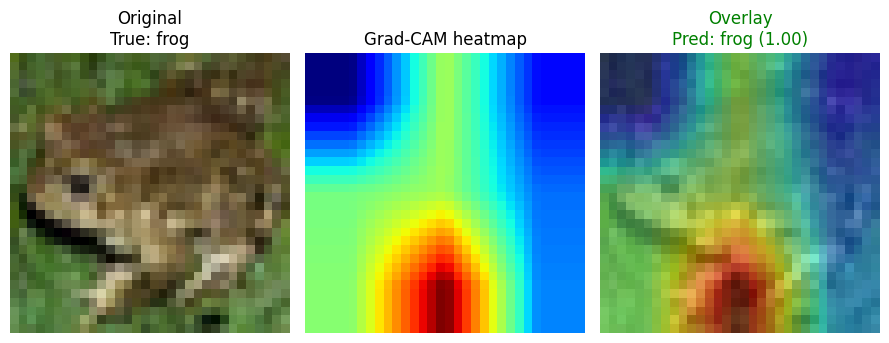

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_correct_1.png
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


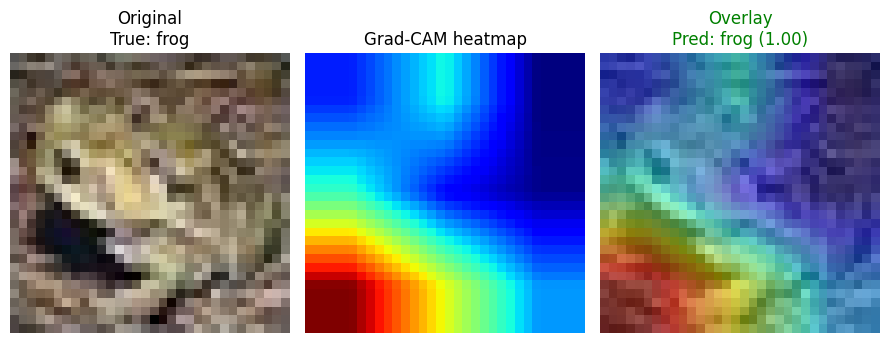

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_correct_2.png
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


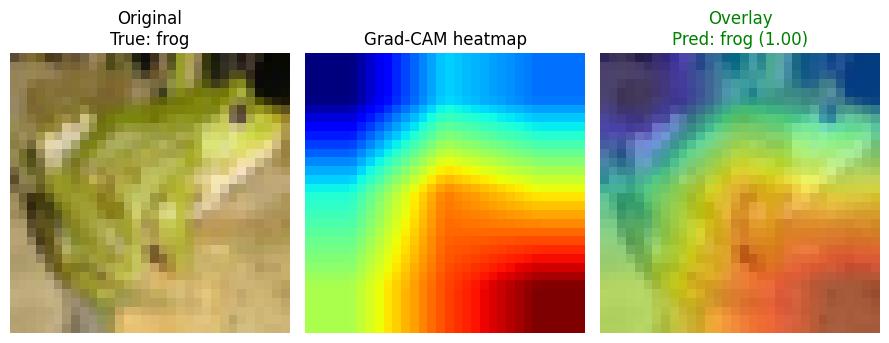

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_correct_3.png
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


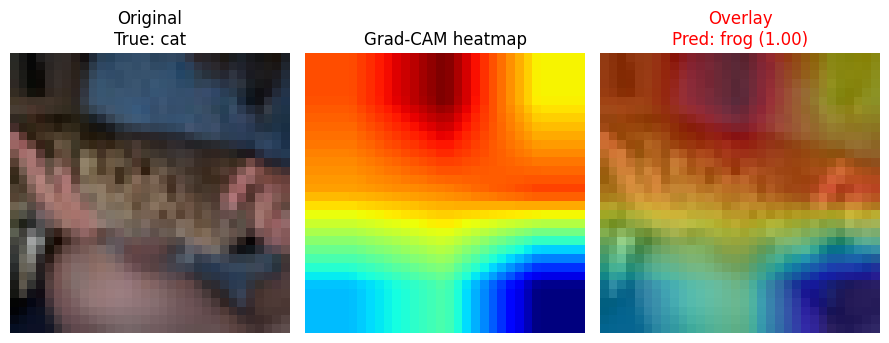

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_wrong_1.png
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


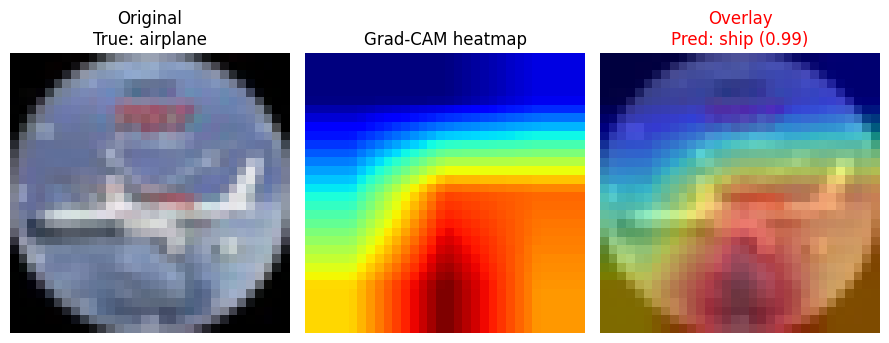

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_wrong_2.png
Targeting backbone: 'resnet50' -> Layer: 'conv5_block3_3_conv'


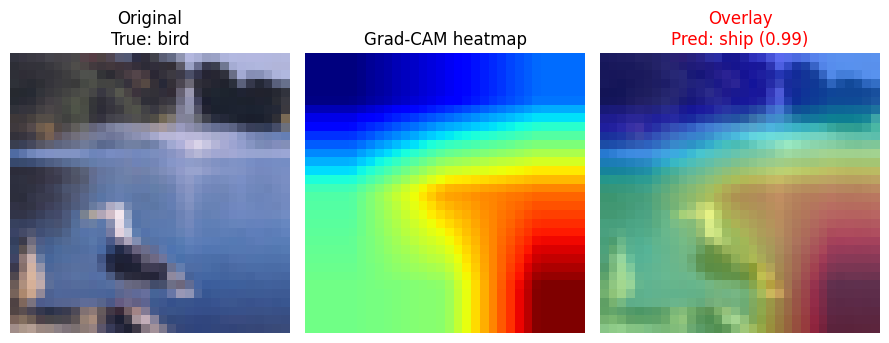

saved c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\reports\figures\gradcam_exp5_transfer_wrong_3.png


In [24]:
def compute_resnet50_gradcam(model, img_array, class_idx):
    """
    Computes Grad-CAM heatmap for a model containing a ResNet50 backbone.
    Dynamically discovers internal layer names to avoid hard-coding layer paths.
    """
    # 1. Dynamically find the backbone model and the absolute last Conv2D layer
    backbone_model = None
    last_conv_layer = None

    # Search recursively for the backbone and its final convolutional layer
    for layer in model.layers:
        if 'resnet50' in layer.name.lower() or hasattr(layer, 'layers'):
            backbone_model = layer
            # Look backward through the backbone layers to find the last Conv2D layer
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    last_conv_layer = sub_layer
                    break
            if last_conv_layer:
                break

    # Fallback safety check if your model layout is structured differently
    if backbone_model is None or last_conv_layer is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer = layer
                backbone_model = model
                break

    if last_conv_layer is None:
        raise ValueError("Could not find any Conv2D layer inside the model structure.")

    print(f"Targeting backbone: '{backbone_model.name}' -> Layer: '{last_conv_layer.name}'")

    # 2. Create a clean preprocessing slice of the layers BEFORE the backbone
    pre_layers = []
    for layer in model.layers:
        if layer.name == backbone_model.name:
            break
        pre_layers.append(layer)

    x = img_array
    if pre_layers:
        pre_model = tf.keras.Sequential(pre_layers)
        x = pre_model(x, training=False)

    # 3. Construct a sub-graph model strictly inside the backbone's boundaries
    backbone_grad_model = Model(
        inputs=backbone_model.inputs,
        outputs=[last_conv_layer.output, backbone_model.output]
    )

    # 4. Track gradients through the backbone and classification head.
    # tape.watch(conv_out) is required: the ResNet50 backbone is frozen
    # (backbone.trainable = False), so its weights are NOT auto-watched by
    # GradientTape. Without this call, TF cannot guarantee it records the
    # path conv_out → GAP → backbone_features, and tape.gradient may return
    # None or zero gradients for a frozen backbone.
    with tf.GradientTape() as tape:
        conv_out, backbone_features = backbone_grad_model(x, training=False)
        tape.watch(conv_out)  # explicitly watch the target spatial tensor

        x_head = backbone_features
        found_backbone = False
        for layer in model.layers:
            if found_backbone:
                try:
                    x_head = layer(inputs=x_head, training=False)
                except TypeError:
                    x_head = layer(inputs=x_head)
            if layer.name == backbone_model.name:
                found_backbone = True

        preds = x_head
        score = preds[:, class_idx]

    # 5. Extract gradients of the class score with respect to the feature map
    grads = tape.gradient(score, conv_out)

    # 6. Global average pool the gradients
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Generate the heatmap matrix multiplication
    heatmap = tf.reduce_sum(conv_out[0] * pooled, axis=-1)

    # 8. Normalize the heatmap using ReLU
    heatmap = tf.maximum(heatmap, 0)
    m = tf.reduce_max(heatmap)
    if m > 0:
        heatmap /= m

    return heatmap.numpy()


def plot_gradcam(img, heatmap, true_lbl, pred_lbl, conf, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
    axes[0].imshow(img)
    axes[0].set_title(f'Original\nTrue: {true_lbl}')
    axes[0].axis('off')

    # Upscale the raw heatmap to image size with bilinear interpolation before
    # displaying it. Without this, the 3x3 feature map from ResNet50 (96/32=3)
    # would be shown as 9 giant solid colour blocks by matplotlib's default
    # nearest-neighbour scaling.
    big = tf.image.resize(heatmap[..., np.newaxis],
                          (img.shape[0], img.shape[1])).numpy()[..., 0]
    axes[1].imshow(big, cmap='jet')
    axes[1].set_title('Grad-CAM heatmap')
    axes[1].axis('off')

    axes[2].imshow(img)
    axes[2].imshow(big, cmap='jet', alpha=0.5)

    color = 'green' if (true_lbl == pred_lbl) else 'red'
    axes[2].set_title(f'Overlay\nPred: {pred_lbl} ({conf:.2f})', color=color)
    axes[2].axis('off')

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


def run_gradcam(run_name: str, n_correct=3, n_wrong=3):
    model_path = MODELS_DIR / f'{run_name}.keras'
    if not model_path.exists():
        print('no model:', model_path)
        return

    if run_name == 'exp5_transfer':
        print(f"Rebuilding {run_name} architecture to load weights safely...")
        model = build_transfer_model()
        model.load_weights(model_path)
    else:
        model = load_model(model_path)

    n_sub = min(2000, len(x_test))
    probs = model.predict(x_test[:n_sub], verbose=0)
    preds = probs.argmax(axis=1)

    correct = np.where(preds == y_test[:n_sub])[0]
    wrong   = np.where(preds != y_test[:n_sub])[0]

    correct_pick = correct[np.argsort(-probs[correct, preds[correct]])][:n_correct]
    wrong_pick   = (wrong[np.argsort(-probs[wrong, preds[wrong]])][:n_wrong]
                    if len(wrong) > 0 else np.array([], dtype=int))

    for label, indices in [('correct', correct_pick), ('wrong', wrong_pick)]:
        for rank, idx in enumerate(indices, start=1):
            img = x_test[idx]
            batch = img[np.newaxis, ...].astype('float32')
            pred_cls = int(preds[idx])

            heatmap = compute_resnet50_gradcam(model, batch, class_idx=pred_cls)

            out = FIGURES_DIR / f'gradcam_{run_name}_{label}_{rank}.png'
            plot_gradcam(img, heatmap, CLASS_NAMES[int(y_test[idx])],
                         CLASS_NAMES[pred_cls], float(probs[idx, pred_cls]), out)
            print('saved', out)
run_gradcam('exp5_transfer')


## 11. Predict a single image

This is the inference endpoint: give it any image path and it returns the predicted class plus the full
probability vector. Useful for quick manual testing.

Running example prediction on: 4_deer\000052.jpg
Rebuilding exp5_transfer architecture to load weights safely...

Prediction for c:\Users\fadyg\Documents\FH-Campus\AIE\resnet50\AIEngineering_CIFAR-10\data\own\4_deer\000052.jpg
  Class      : deer (index 4)
  Confidence : 0.87
  All probabilities:
    airplane  : 0.00
    automobile: 0.00
    bird      : 0.08
    cat       : 0.00
    deer      : 0.87   <-- predicted
    dog       : 0.00
    frog      : 0.04
    horse     : 0.00
    ship      : 0.00
    truck     : 0.00


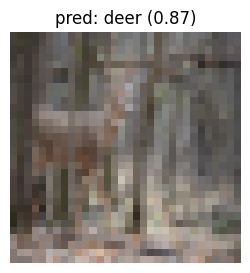

In [32]:
def predict_image(image_path, run_name: str = 'exp5_transfer', show: bool = True):
    model_path = MODELS_DIR / f'{run_name}.keras'
    if not model_path.exists():
        raise FileNotFoundError(f'no model at {model_path} — train first.')
    if run_name == 'exp5_transfer':
        print(f"Rebuilding {run_name} architecture to load weights safely...")
        model = build_transfer_model()
        model.load_weights(model_path)
    else:
        model = load_model(model_path)
    img_pil = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img_pil, dtype=np.uint8)[np.newaxis, ...]
    probs = model.predict(arr, verbose=0)[0]
    top = int(probs.argmax())
    print(f'\nPrediction for {image_path}')
    print(f'  Class      : {CLASS_NAMES[top]} (index {top})')
    print(f'  Confidence : {probs[top]:.2f}')
    print('  All probabilities:')
    for i, name in enumerate(CLASS_NAMES):
        marker = '   <-- predicted' if i == top else ''
        print(f'    {name:10s}: {probs[i]:.2f}{marker}')
    if show:
        plt.figure(figsize=(3, 3))
        plt.imshow(img_pil); plt.axis('off')
        plt.title(f'pred: {CLASS_NAMES[top]} ({probs[top]:.2f})')
        plt.show()
    return CLASS_NAMES[top], float(probs[top]), {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}

# --- Example: pick one random own image from whatever classes are available ---
# exists() must guard iterdir() — wrong order causes FileNotFoundError on missing folders.
# No fixed seed here so a different image is shown on each run.
import random as _random
all_own = [
    f
    for ci, name in enumerate(CLASS_NAMES)
    if (OWN_DIR / f'{ci}_{name}').exists()
    for f in sorted((OWN_DIR / f'{ci}_{name}').iterdir())
    if f.suffix.lower() in SUPPORTED_EXT
]
if all_own:
    example = _random.choice(all_own)
    print(f'Running example prediction on: {example.relative_to(OWN_DIR)}')
    predict_image(example, run_name='exp5_transfer')
else:
    print('No own images found in data/own/. Add some images and re-run.')
